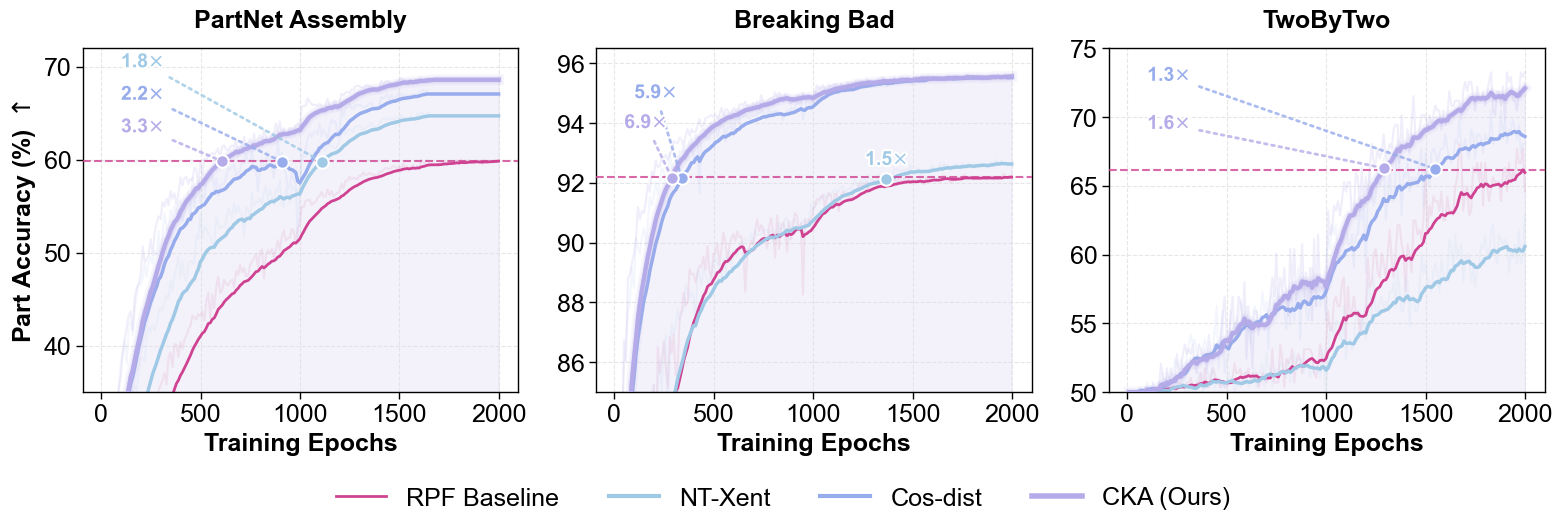

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
FIG_WIDTH = 16
FIG_HEIGHT = 5.0

COLOR_BASELINE = (207/255,  66/255, 145/255)  
COLOR_NT_XENT  = (160/255, 201/255, 230/255)  
COLOR_COS_DIST = (151/255, 172/255, 236/255)  
COLOR_CKA      = (181/255, 171/255, 232/255)  

EMA_SPAN = 15
INTERSECTION_TOLERANCE = 0.1  # 점선 돌파 기준의 오차 허용치 (%)

# 💡 [직접 조절 가능] 1. 각 데이터셋별 Y축 (y_min, y_max) 줌인 범위 설정
Y_LIMITS = {
    'PartNet':      {'y_min': 35.0, 'y_max': 72.0},  
    'Breaking Bad': {'y_min': 85.0, 'y_max': 96.5},  
    '2by2':         {'y_min': 50.0, 'y_max': 75.0}   
}

# 💡 [직접 조절 가능] 2. 텍스트 박스가 그려질 (x, y) 좌표 설정
ANNOTATE_POS = {
    'PartNet': {
        'NT-Xent':  (100, 70.5), # 상단
        'Cos-dist': (100, 67.0),
        'CKA':      (100, 63.5)  # 하단
    },
    'Breaking Bad': {
        'NT-Xent':  None,        # None은 좌표 이동 없이 점 바로 위에 렌더링
        'Cos-dist': (100, 95.0), # 상단
        'CKA':      (50, 94.0)   # 하단
    },
    '2by2': {
        'NT-Xent':  (100, 76.5), # 상단
        'Cos-dist': (100, 73.0),
        'CKA':      (100, 69.5)  # 하단
    }
}
# ==========================================

plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'legend.fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'font.family': 'Arial', 
    'axes.facecolor': '#FFFFFF', 
    'figure.facecolor': 'white',
})

datasets = ['PartNet', 'Breaking Bad', '2by2']
csv_files = ['csv/pa_epoch_partnet.csv', 'csv/pa_epoch_bbad.csv', 'csv/pa_epoch_2by2.csv'] 
dataset_titles = ['PartNet Assembly', 'Breaking Bad', 'TwoByTwo']

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

for i, (dataset, csv_file, title) in enumerate(zip(datasets, csv_files, dataset_titles)):
    ax = axes[i]
    df = pd.read_csv(csv_file)
    epochs = df['epoch']
    
    # Scale to %
    pa_base = df['RPF_base'] * 100
    pa_nt   = df['NT-Xent'] * 100
    pa_cos  = df['Cos'] * 100
    pa_cka  = df['CKA'] * 100
    
    # EMA Smoothing
    pa_base_sm = pa_base.ewm(span=EMA_SPAN).mean()
    pa_nt_sm   = pa_nt.ewm(span=EMA_SPAN).mean()
    pa_cos_sm  = pa_cos.ewm(span=EMA_SPAN).mean()
    pa_cka_sm  = pa_cka.ewm(span=EMA_SPAN).mean()
    
    # Raw Data 배경선
    ax.plot(epochs, pa_base, color=COLOR_BASELINE, alpha=0.1)
    ax.plot(epochs, pa_nt,   color=COLOR_NT_XENT,  alpha=0.1)
    ax.plot(epochs, pa_cos,  color=COLOR_COS_DIST, alpha=0.1)
    ax.plot(epochs, pa_cka,  color=COLOR_CKA,      alpha=0.2)
    
    # Smoothed 메인 선
    ax.plot(epochs, pa_base_sm, color=COLOR_BASELINE, label='RPF Baseline', linewidth=2, linestyle='-')
    ax.plot(epochs, pa_nt_sm,   color=COLOR_NT_XENT,  label='NT-Xent', linewidth=2.5)
    ax.plot(epochs, pa_cos_sm,  color=COLOR_COS_DIST, label='Cos-dist', linewidth=2.5)
    
    # CKA Glow Effect & Main Line
    for lw, alpha in zip([8, 5, 3], [0.1, 0.2, 0.5]):
        ax.plot(epochs, pa_cka_sm, color=COLOR_CKA, linewidth=lw, alpha=alpha, zorder=4)
    ax.plot(epochs, pa_cka_sm, color=COLOR_CKA, label='CKA (Ours)', linewidth=3, zorder=5)
    
    # RPF Baseline 최고 성능(Max)에 가로 점선 추가
    base_max_val = pa_base_sm.max()
    ax.axhline(base_max_val, color=COLOR_BASELINE, linestyle='--', linewidth=1.5, alpha=0.8, zorder=3)
    
    y_range = Y_LIMITS[dataset]['y_max'] - Y_LIMITS[dataset]['y_min']
    text_y_offset = y_range * 0.03
    
    # 마커 및 수렴 속도(x배) 어노테이션 추가
    method_names = ['NT-Xent', 'Cos-dist', 'CKA']
    series_colors = zip([pa_nt_sm, pa_cos_sm, pa_cka_sm], [COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA], method_names)
    
    for sm_series, line_color, m_name in series_colors:
        cross_indices = np.where(sm_series >= (base_max_val - INTERSECTION_TOLERANCE))[0]
        
        if len(cross_indices) > 0:
            first_cross_idx = cross_indices[0] 
            cross_epoch = epochs.iloc[first_cross_idx]
            cross_val = sm_series.iloc[first_cross_idx]
            
            # 교차점 렌더링
            ax.plot(cross_epoch, cross_val, marker='o', markersize=9, 
                    color=line_color, markeredgecolor='white', markeredgewidth=1.5, zorder=10)
            
            # 수렴 배수(Speedup) 계산
            if cross_epoch > 0:
                speedup = 2000.0 / cross_epoch
                text_str = f"{speedup:.1f}$\\times$"
                
                pos = ANNOTATE_POS[dataset][m_name]
                if pos is not None:
                    ax.annotate(text_str,
                                xy=(cross_epoch, cross_val),
                                xytext=pos,
                                color=line_color, fontsize=14, fontweight='bold', 
                                ha='left', va='center', zorder=11,
                                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                                arrowprops=dict(arrowstyle="-", color=line_color, 
                                                linestyle=":", linewidth=2, alpha=0.8,
                                                shrinkA=5, shrinkB=5))
                else:
                    ax.text(cross_epoch, cross_val + text_y_offset, text_str, 
                            color=line_color, fontsize=14, fontweight='bold', 
                            ha='center', va='bottom', zorder=11,
                            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

    # CKA 곡선 하단 색상 채우기
    y_min_val = Y_LIMITS[dataset]['y_min']
    ax.fill_between(epochs, y_min_val, pa_cka_sm, color=COLOR_CKA, alpha=0.15, zorder=1)

    # ==========================================================
    # 💡 4면의 테두리(Spines)를 모두 검정색으로 설정!
    # ==========================================================
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0) # 기본 1.0 두께 (필요시 조절)
    
    ax.tick_params(axis='both', colors='black', width=1.0, length=5)
    
    ax.set_title(title, fontweight='heavy', pad=15, color='black')
    ax.set_xlabel('Training Epochs', fontweight='bold', color='black')
    if i == 0:
        ax.set_ylabel(r'Part Accuracy (%) $\uparrow$', fontweight='bold', color='black')
    
    ax.grid(True, linestyle='--', color='#E0E0E0', alpha=0.8, zorder=0)
    
    ax.set_ylim(Y_LIMITS[dataset]['y_min'], Y_LIMITS[dataset]['y_max'])

# 하단 범례 설정
custom_lines = [
    Line2D([0], [0], color=COLOR_BASELINE, linestyle='-', linewidth=2),
    Line2D([0], [0], color=COLOR_NT_XENT, linewidth=3),
    Line2D([0], [0], color=COLOR_COS_DIST, linewidth=3),
    Line2D([0], [0], color=COLOR_CKA, linewidth=4)
]
legend_labels = ['RPF Baseline', 'NT-Xent', 'Cos-dist', 'CKA (Ours)']

# 범례 테두리 박스 제거 (frameon=False)
leg = fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1), frameon=False)

# 범례 텍스트 완전한 검정색
for text in leg.get_texts():
    text.set_color('black')

plt.tight_layout()
plt.savefig('fancy_convergence_black_border.pdf', bbox_inches='tight') 
plt.show()

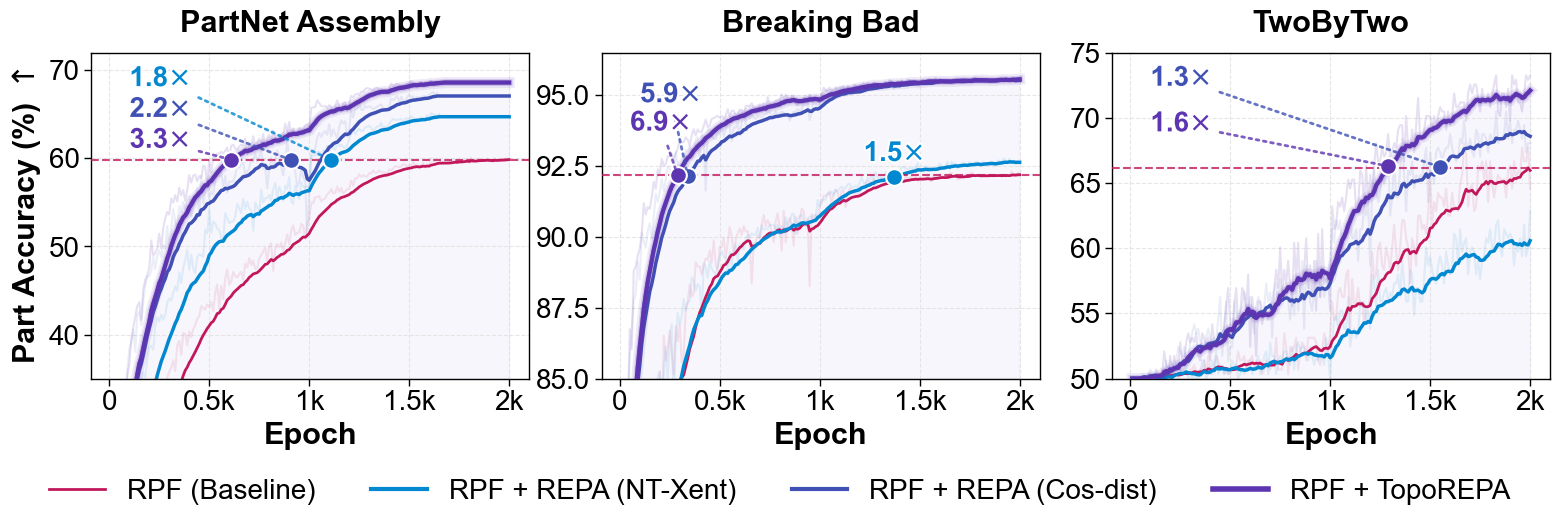

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# ==========================================
# 🎯 [USER CONFIGURATION] 사용자 커스텀 설정
# ==========================================
FIG_WIDTH = 16
FIG_HEIGHT = 5.0

# 선과 마커를 위한 쨍한 색상 (수정된 진한 색)
COLOR_BASELINE = '#C2185B'  
COLOR_NT_XENT  = '#0288D1'  
COLOR_COS_DIST = '#3F51B5'  
COLOR_CKA      = '#5E35B1'  

# 💡 곡선 아래 채우기용 색상 (원래의 파스텔 보라색을 별도로 유지!)
COLOR_CKA_FILL = (181/255, 171/255, 232/255)

EMA_SPAN = 15
INTERSECTION_TOLERANCE = 0.1  

ANNOTATION_FONT_SIZE = 20

Y_LIMITS = {
    'PartNet':      {'y_min': 35.0, 'y_max': 72.0},  
    'Breaking Bad': {'y_min': 85.0, 'y_max': 96.5},  
    '2by2':         {'y_min': 50.0, 'y_max': 75.0}   
}

ANNOTATE_POS = {
    'PartNet': {
        'NT-Xent':  (100, 69.0), 
        'Cos-dist': (100, 65.5),
        'CKA':      (100, 62.0)  
    },
    'Breaking Bad': {
        'NT-Xent':  None,        
        'Cos-dist': (100, 95.0), 
        'CKA':      (50, 94.0)   
    },
    '2by2': {
        'NT-Xent':  (100, 76.5), 
        'Cos-dist': (100, 73.0),
        'CKA':      (100, 69.5)  
    }
}
# ==========================================

plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 22,
    'axes.titlesize': 22,
    'legend.fontsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'font.family': 'Arial', 
    'axes.facecolor': '#FFFFFF', 
    'figure.facecolor': 'white',
})

datasets = ['PartNet', 'Breaking Bad', '2by2']
csv_files = ['csv/pa_epoch_partnet.csv', 'csv/pa_epoch_bbad.csv', 'csv/pa_epoch_2by2.csv'] 
dataset_titles = ['PartNet Assembly', 'Breaking Bad', 'TwoByTwo']

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT))

def k_formatter(x, pos):
    if x == 0:
        return '0'
    elif x % 1000 == 0:
        return f'{int(x/1000)}k'
    else:
        return f'{x/1000:.1f}k' 

for i, (dataset, csv_file, title) in enumerate(zip(datasets, csv_files, dataset_titles)):
    ax = axes[i]
    df = pd.read_csv(csv_file)
    epochs = df['epoch']
    
    pa_base = df['RPF_base'] * 100
    pa_nt   = df['NT-Xent'] * 100
    pa_cos  = df['Cos'] * 100
    pa_cka  = df['CKA'] * 100
    
    pa_base_sm = pa_base.ewm(span=EMA_SPAN).mean()
    pa_nt_sm   = pa_nt.ewm(span=EMA_SPAN).mean()
    pa_cos_sm  = pa_cos.ewm(span=EMA_SPAN).mean()
    pa_cka_sm  = pa_cka.ewm(span=EMA_SPAN).mean()
    
    # 옅은 Raw Data
    ax.plot(epochs, pa_base, color=COLOR_BASELINE, alpha=0.1)
    ax.plot(epochs, pa_nt,   color=COLOR_NT_XENT,  alpha=0.1)
    ax.plot(epochs, pa_cos,  color=COLOR_COS_DIST, alpha=0.1)
    ax.plot(epochs, pa_cka,  color=COLOR_CKA,      alpha=0.15) # Raw data 색상도 살짝 연하게
    
    ax.plot(epochs, pa_base_sm, color=COLOR_BASELINE, label='RPF Baseline', linewidth=2, linestyle='-')
    ax.plot(epochs, pa_nt_sm,   color=COLOR_NT_XENT,  label='NT-Xent', linewidth=2.5)
    ax.plot(epochs, pa_cos_sm,  color=COLOR_COS_DIST, label='Cos-dist', linewidth=2.5)
    
    for lw, alpha in zip([8, 5, 3], [0.1, 0.2, 0.5]):
        ax.plot(epochs, pa_cka_sm, color=COLOR_CKA, linewidth=lw, alpha=alpha, zorder=4)
    ax.plot(epochs, pa_cka_sm, color=COLOR_CKA, label='CKA (Ours)', linewidth=3, zorder=5)
    
    base_max_val = pa_base_sm.max()
    ax.axhline(base_max_val, color=COLOR_BASELINE, linestyle='--', linewidth=1.5, alpha=0.8, zorder=3)
    
    y_range = Y_LIMITS[dataset]['y_max'] - Y_LIMITS[dataset]['y_min']
    text_y_offset = y_range * 0.03
    
    method_names = ['NT-Xent', 'Cos-dist', 'CKA']
    series_colors = zip([pa_nt_sm, pa_cos_sm, pa_cka_sm], [COLOR_NT_XENT, COLOR_COS_DIST, COLOR_CKA], method_names)
    
    for sm_series, line_color, m_name in series_colors:
        cross_indices = np.where(sm_series >= (base_max_val - INTERSECTION_TOLERANCE))[0]
        
        if len(cross_indices) > 0:
            first_cross_idx = cross_indices[0] 
            cross_epoch = epochs.iloc[first_cross_idx]
            cross_val = sm_series.iloc[first_cross_idx]
            
            ax.plot(cross_epoch, cross_val, marker='o', markersize=12, 
                    color=line_color, markeredgecolor='white', markeredgewidth=1.5, zorder=10)
            
            if cross_epoch > 0:
                speedup = 2000.0 / cross_epoch
                text_str = f"{speedup:.1f}$\\times$"
                
                pos = ANNOTATE_POS[dataset][m_name]
                if pos is not None:
                    ax.annotate(text_str,
                                xy=(cross_epoch, cross_val),
                                xytext=pos,
                                color=line_color, fontsize=ANNOTATION_FONT_SIZE, fontweight='bold', 
                                ha='left', va='center', zorder=11,
                                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
                                arrowprops=dict(arrowstyle="-", color=line_color, 
                                                linestyle=":", linewidth=2, alpha=0.8,
                                                shrinkA=5, shrinkB=5))
                else:
                    ax.text(cross_epoch, cross_val + text_y_offset, text_str, 
                            color=line_color, fontsize=ANNOTATION_FONT_SIZE, fontweight='bold', 
                            ha='center', va='bottom', zorder=11,
                            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

    y_min_val = Y_LIMITS[dataset]['y_min']
    
    # 💡 [핵심 수정] CKA 곡선 밑 칠하기용 색상을 예전의 투명한 라벤더색(COLOR_CKA_FILL)으로 독립 적용!
    ax.fill_between(epochs, y_min_val, pa_cka_sm, color=COLOR_CKA_FILL, alpha=0.10, zorder=1)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.0)
    
    ax.tick_params(axis='both', colors='black', width=1.0, length=5)
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(k_formatter))
    
    ax.set_title(title, fontweight='heavy', pad=15, color='black')
    ax.set_xlabel('Epoch', fontweight='bold', color='black')
    if i == 0:
        ax.set_ylabel(r'Part Accuracy (%) $\uparrow$', fontweight='bold', color='black')
    
    ax.grid(True, linestyle='--', color='#E0E0E0', alpha=0.8, zorder=0)
    ax.set_ylim(Y_LIMITS[dataset]['y_min'], Y_LIMITS[dataset]['y_max'])

custom_lines = [
    Line2D([0], [0], color=COLOR_BASELINE, linestyle='-', linewidth=2),
    Line2D([0], [0], color=COLOR_NT_XENT, linewidth=3),
    Line2D([0], [0], color=COLOR_COS_DIST, linewidth=3),
    Line2D([0], [0], color=COLOR_CKA, linewidth=4)
]
legend_labels = ['RPF (Baseline)', 'RPF + REPA (NT-Xent)', 'RPF + REPA (Cos-dist)', 'RPF + TopoREPA']

leg = fig.legend(custom_lines, legend_labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1), frameon=False)
for text in leg.get_texts():
    text.set_color('black')

plt.tight_layout()
plt.savefig('convergence.pdf', bbox_inches='tight') 
plt.show()